# Trabalho de Inteligência Artificial - CNN para GTSRB

### Experimento Opcional 6.1 — Arquitetura Alternativa: ResNet-18 treinada do zero vs Baseline (EHMNet)

> **Regra do trabalho:** modelos pré-treinados **não são permitidos**.
> A ResNet-18 abaixo é implementada do zero e treinada inteiramente no GTSRB.
>
> **Adaptação para imagens 32x32:** a ResNet-18 original usa conv 7x7 stride 2 + MaxPool,
> o que reduziria imagens 32x32 para 4x4 já na entrada. Para imagens pequenas,
> substituímos por conv 3x3 stride 1 e removemos o MaxPool inicial — padrão usado em CIFAR-10.

### 1. Setup

In [4]:
from genericpath import exists
#!/usr/bin/env python3
import os
import json
import torch
import torch.nn as nn
import torch.optim as optim
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from src.gtsrb import NUM_CLASSES, GTSRB_CLASSES, get_dataloaders, save_predictions

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

model_pth_path = '/content/models_pth'
if not os.path.exists(model_pth_path):
    os.mkdir(model_pth_path)

figs_path = '/content/figs'
if not os.path.exists(figs_path):
    os.mkdir(figs_path)

checkpoints_path = '/content/checkpoints'
if not os.path.exists(checkpoints_path):
    os.mkdir(checkpoints_path)

results_path = '/content/results'
if not os.path.exists(results_path):
    os.mkdir(results_path)


Using device: cuda


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### 2. Funções de treino e avaliação

In [5]:
def train(trainloader, model, criterion, optimizer, device) -> tuple[float, float]:
    total_loss, correct, total = 0.0, 0, 0
    model.train()
    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)
    return total_loss / total, correct / total

def validate(val_loader, model, device) -> tuple[float, float]:
    total_loss, correct, total = 0.0, 0, 0
    model.eval()
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)
            correct += (outputs.argmax(dim=1) == labels).sum().item()
            total += labels.size(0)
    return total_loss / total, correct / total

def get_confusion_matrix(loader, num_classes, model):
    cm = np.zeros((num_classes, num_classes), dtype=np.int64)
    model.eval()
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            for t, p in zip(labels.cpu().numpy(), predicted.cpu().numpy()):
                cm[t, p] += 1
    return cm

def get_acc_by_class(cm):
    acc = np.zeros(NUM_CLASSES)
    for i in range(NUM_CLASSES):
        if cm[i].sum() > 0:
            acc[i] = cm[i, i] / cm[i].sum()
    return acc

def plot_history_metrics(acc_dict, loss_dict):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    epochs = range(1, len(acc_dict['train']) + 1)
    axes[0].plot(epochs, acc_dict['train'], label='Treino',    color='blue')
    axes[0].plot(epochs, acc_dict['val'],   label='Validação', color='orange')
    axes[0].set_title('Acurácia por Época')
    axes[0].set_xlabel('Épocas')
    axes[0].set_ylabel('Acurácia')
    axes[0].legend()
    axes[1].plot(epochs, loss_dict['train'], label='Treino',    color='blue')
    axes[1].plot(epochs, loss_dict['val'],   label='Validação', color='orange')
    axes[1].set_title('Loss por Época')
    axes[1].set_xlabel('Épocas')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    plt.tight_layout()
    plt.show()

def plot_confusion_matrix(cm):
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm_norm, annot=False, cmap='Blues',
                xticklabels=np.arange(NUM_CLASSES),
                yticklabels=np.arange(NUM_CLASSES),
                vmin=0, vmax=1, linewidths=0.5,
                linecolor='white', square=True)
    plt.ylabel('Real')
    plt.xlabel('Predito')
    plt.title('Matriz de Confusão (normalizada)')
    plt.tight_layout()
    plt.show()

def plot_acc_by_class(acc_by_class, title='Acurácia por Classe'):
    plt.figure(figsize=(12, 5))
    plt.bar(np.arange(NUM_CLASSES), acc_by_class, color='blue')
    plt.xlabel('Classe')
    plt.ylabel('Acurácia')
    plt.title(title)
    plt.xticks(np.arange(NUM_CLASSES))
    plt.ylim(0, 1.05)
    plt.tight_layout()
    plt.show()

In [6]:
def predict(loader, model, device):
    ytrue, ypred = [], []
    model.eval()
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            preds  = model(images).argmax(1).cpu().numpy()
            ytrue.append(labels.numpy())
            ypred.append(preds)
    return np.concatenate(ytrue), np.concatenate(ypred)

def per_class_accuracy(ytrue, ypred):
    acc = np.zeros(NUM_CLASSES)
    for c in range(NUM_CLASSES):
        mask = ytrue == c
        if mask.sum() > 0:
            acc[c] = (ypred[mask] == ytrue[mask]).mean()
    return acc


### Funções de salvamento e carregamento de modelos

In [7]:
def save_model(model, file_name, path=model_pth_path):
    PATH = f'{path}/{file_name}'
    torch.save(model.state_dict(), PATH)
    return PATH

def load_ehmnet(file_name, path=model_pth_path):
    PATH = f'{path}/{file_name}'
    model = EHMNet()
    model.load_state_dict(torch.load(PATH))
    return model

def load_resnet(file_name, path=model_pth_path):
    PATH = f'{path}/{file_name}'
    model = ResNet18(num_classes=NUM_CLASSES)
    model.load_state_dict(torch.load(PATH))
    return model


### 3. Definindo as Arquiteturas

#### 3.1 Baseline — EHMNet (CNN simples)

In [8]:
class EHMNet(nn.Module):
    def __init__(self, num_classes: int = 43, img_size: int = 32):
        super(EHMNet, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, stride=1, padding='same')
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding='same')
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        spatial = img_size // 4
        flatten_size = 64 * spatial * spatial
        self.fc1 = nn.Linear(in_features=flatten_size, out_features=256)
        self.fc2 = nn.Linear(in_features=256, out_features=num_classes)

    def forward(self, x):
        x = self.pool1(torch.relu(self.conv1(x)))
        x = self.pool2(torch.relu(self.conv2(x)))
        x = torch.flatten(x, 1)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

#### 3.2 ResNet-18 implementada do zero

In [9]:
# Bloco residual básico — implementação seguindo o padrão do professor
from typing import Optional

class BasicBlock(nn.Module):
    """Bloco residual com duas convoluções 3x3."""
    expansion: int = 1

    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        stride: int = 1,
        downsample: Optional[nn.Module] = None,  # projeção 1x1 quando necessário
    ) -> None:
        super().__init__()
        # Primeira convolução: pode fazer downsampling (stride > 1)
        self.conv1 = nn.Conv2d(
            in_channels, out_channels,
            kernel_size=3, stride=stride, padding=1, bias=False
        )
        self.bn1  = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)  # inplace=True economiza memória

        # Segunda convolução: sempre stride=1
        self.conv2 = nn.Conv2d(
            out_channels, out_channels,
            kernel_size=3, stride=1, padding=1, bias=False
        )
        self.bn2 = nn.BatchNorm2d(out_channels)

        # Shortcut: None = identidade; ou Conv1x1+BN para ajustar canais/resolução
        self.downsample = downsample

    def forward(self, x):
        identity = x

        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))

        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity   # <-- conexão residual!
        out = self.relu(out)
        return out


class ResNet18(nn.Module):
    """
    ResNet-18 adaptada para imagens 32x32 (GTSRB).

    Diferenças em relação à ResNet-18 original (ImageNet 224x224):
      - Conv inicial: 7x7 stride 2  -->  3x3 stride 1  (preserva resolução)
      - MaxPool inicial: removido   (evita redução excessiva em 32x32)

    Fluxo de resolução para entrada 32x32:
      Input      : 32x32  (3 canais)
      Conv inicial: 32x32  (64 canais)
      Layer1     : 32x32  (64 canais)
      Layer2     : 16x16  (128 canais)  <- stride 2
      Layer3     :  8x8   (256 canais)  <- stride 2
      Layer4     :  4x4   (512 canais)  <- stride 2
      AvgPool    :  1x1   (512 canais)
      FC         :  43 classes
    """
    def __init__(self, num_classes: int = 43) -> None:
        super().__init__()

        # Conv inicial adaptada para 32x32 (sem stride 2 e sem MaxPool)
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(64)
        self.relu  = nn.ReLU(inplace=True)
        # self.maxpool removido (desnecessário para 32x32)

        # 4 stages com 2 BasicBlocks cada (= ResNet-18)
        self.layer1 = self._make_layer(64,  64,  num_blocks=2, stride=1)
        self.layer2 = self._make_layer(64,  128, num_blocks=2, stride=2)
        self.layer3 = self._make_layer(128, 256, num_blocks=2, stride=2)
        self.layer4 = self._make_layer(256, 512, num_blocks=2, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc      = nn.Linear(512 * BasicBlock.expansion, num_classes)

        self._init_weights()

    @staticmethod
    def _make_layer(
        in_channels: int, out_channels: int, num_blocks: int, stride: int
    ) -> nn.Sequential:
        """Constrói um stage com num_blocks BasicBlocks."""
        downsample: Optional[nn.Module] = None

        # Downsample necessário quando muda resolução ou número de canais
        if stride != 1 or in_channels != out_channels:
            downsample = nn.Sequential(
                nn.Conv2d(in_channels, out_channels,
                          kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

        layers = [BasicBlock(in_channels, out_channels, stride, downsample)]
        for _ in range(1, num_blocks):
            layers.append(BasicBlock(out_channels, out_channels))

        return nn.Sequential(*layers)

    def _init_weights(self) -> None:
        """Inicialização Kaiming (padrão do paper original da ResNet)."""
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        # sem maxpool (adaptação para 32x32)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x


# Verificando parâmetros de cada modelo
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'EHMNet    : {count_params(EHMNet()):>10,} parâmetros')
print(f'ResNet-18 : {count_params(ResNet18()):>10,} parâmetros')


EHMNet    :  1,079,275 parâmetros
ResNet-18 : 11,190,891 parâmetros


### 4. Hiperparâmetros e carregamento dos dados

In [34]:
IMG_SIZE   = 32
BATCH_SIZE = 128
NUM_EPOCHS = 25
LR         = 0.001

train_loader, val_loader, test_loader = get_dataloaders(img_size=IMG_SIZE, batch_size=BATCH_SIZE)

print(f'train_loader : {len(train_loader)} batches')
print(f'val_loader   : {len(val_loader)} batches')
print(f'test_loader  : {len(test_loader)} batches')

train_loader : 167 batches
val_loader   : 42 batches
test_loader  : 99 batches


### 5. Treinamento

In [35]:
best_models = {
    'ehmnet': {
        'acc': 0.0, 'model': None,
        'history_loss_train': [], 'history_loss_val': [],
        'history_acc_train':  [], 'history_acc_val':  []
    },
    'resnet18': {
        'acc': 0.0, 'model': None,
        'history_loss_train': [], 'history_loss_val': [],
        'history_acc_train':  [], 'history_acc_val':  []
    }
}

In [37]:
# Salva resumo dos experimentos (espelhando o padrão do exp1)
all_results = {}


### Executando testes com EHMNet (Baseline)

In [38]:
model = EHMNet().to(device)
print('Using GPU' if torch.cuda.is_available() else 'Using CPU')

Using GPU


In [39]:
flag_model = 'ehmnet'
file_name  = 'best_ehmnet_resnet_exp.pth'

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)

for e in range(NUM_EPOCHS):
    train_loss, train_acc = train(train_loader, model, criterion, optimizer, device)
    val_loss, val_acc     = validate(val_loader, model, device)

    if val_acc > best_models[flag_model]['acc']:
        best_models[flag_model]['acc']   = val_acc
        best_models[flag_model]['model'] = model

    best_models[flag_model]['history_loss_train'].append(train_loss)
    best_models[flag_model]['history_loss_val'].append(val_loss)
    best_models[flag_model]['history_acc_train'].append(train_acc)
    best_models[flag_model]['history_acc_val'].append(val_acc)

    if (e + 1) % (NUM_EPOCHS // 10) == 0:
        print(f'Epoch {(e+1):02d}/{NUM_EPOCHS} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}')

save_model(best_models[flag_model]['model'], file_name)

Epoch 02/25 | Train Loss: 0.2505 | Train Acc: 0.9299 | Val Loss: 0.1572 | Val Acc: 0.9587
Epoch 04/25 | Train Loss: 0.0597 | Train Acc: 0.9847 | Val Loss: 0.0827 | Val Acc: 0.9797
Epoch 06/25 | Train Loss: 0.0288 | Train Acc: 0.9931 | Val Loss: 0.0939 | Val Acc: 0.9739
Epoch 08/25 | Train Loss: 0.0210 | Train Acc: 0.9946 | Val Loss: 0.0735 | Val Acc: 0.9797
Epoch 10/25 | Train Loss: 0.0101 | Train Acc: 0.9978 | Val Loss: 0.0467 | Val Acc: 0.9891
Epoch 12/25 | Train Loss: 0.0073 | Train Acc: 0.9987 | Val Loss: 0.0378 | Val Acc: 0.9917
Epoch 14/25 | Train Loss: 0.0285 | Train Acc: 0.9929 | Val Loss: 0.0636 | Val Acc: 0.9827
Epoch 16/25 | Train Loss: 0.0148 | Train Acc: 0.9964 | Val Loss: 0.0557 | Val Acc: 0.9844
Epoch 18/25 | Train Loss: 0.0209 | Train Acc: 0.9947 | Val Loss: 0.0378 | Val Acc: 0.9906
Epoch 20/25 | Train Loss: 0.0174 | Train Acc: 0.9964 | Val Loss: 0.0466 | Val Acc: 0.9869
Epoch 22/25 | Train Loss: 0.0029 | Train Acc: 0.9994 | Val Loss: 0.0254 | Val Acc: 0.9940
Epoch 24/2

'/content/models_pth/best_ehmnet_resnet_exp.pth'

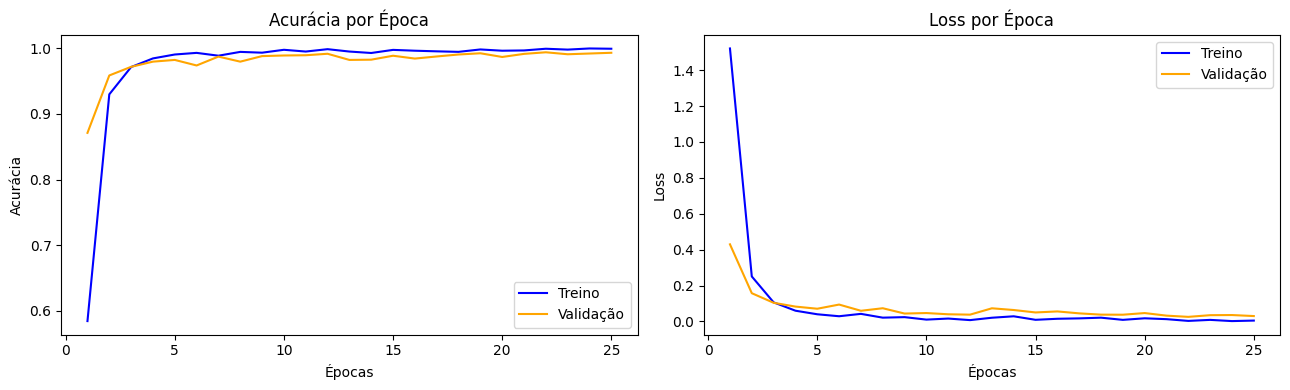

In [40]:
plot_history_metrics(
    {'train': best_models['ehmnet']['history_acc_train'],
     'val':   best_models['ehmnet']['history_acc_val']},
    {'train': best_models['ehmnet']['history_loss_train'],
     'val':   best_models['ehmnet']['history_loss_val']}
)

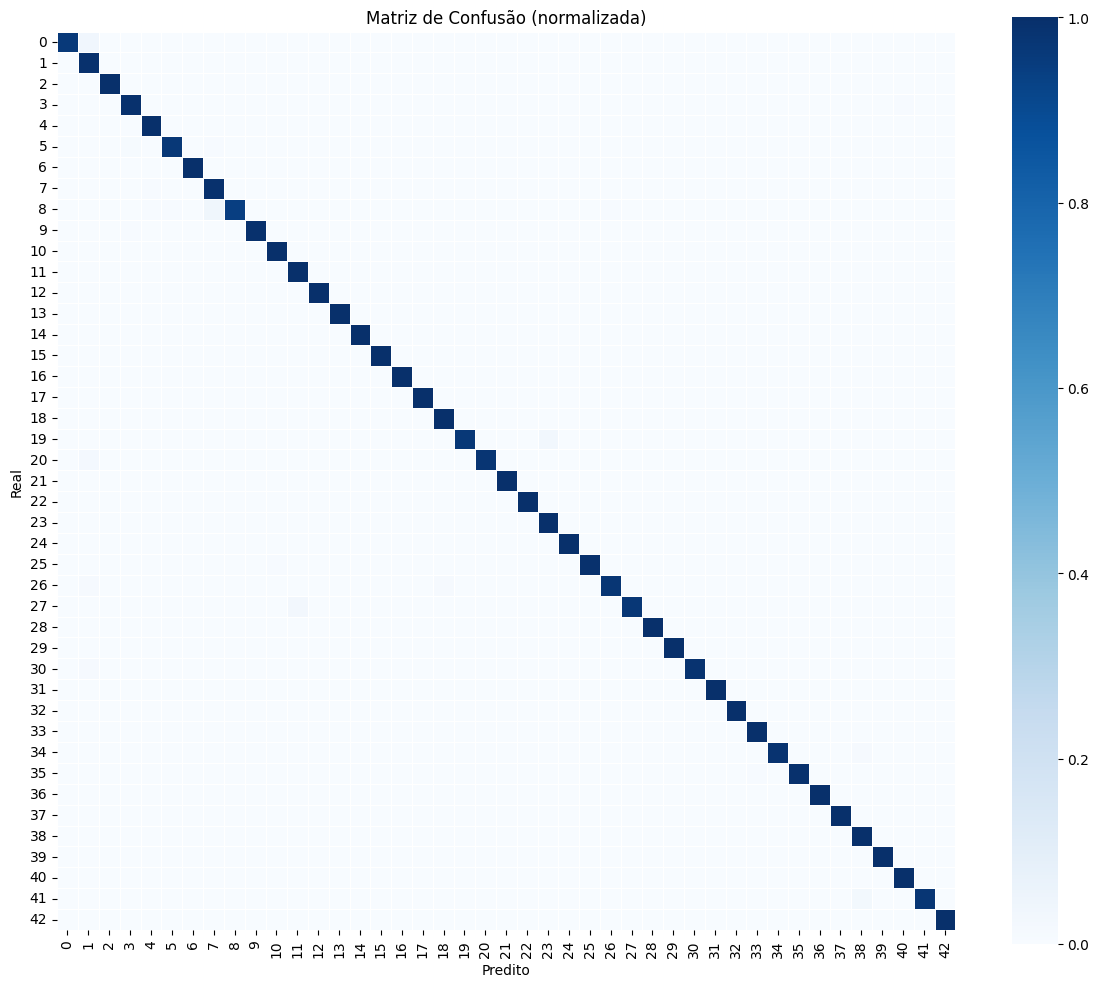

In [41]:
cm = get_confusion_matrix(val_loader, NUM_CLASSES, model)
plot_confusion_matrix(cm)

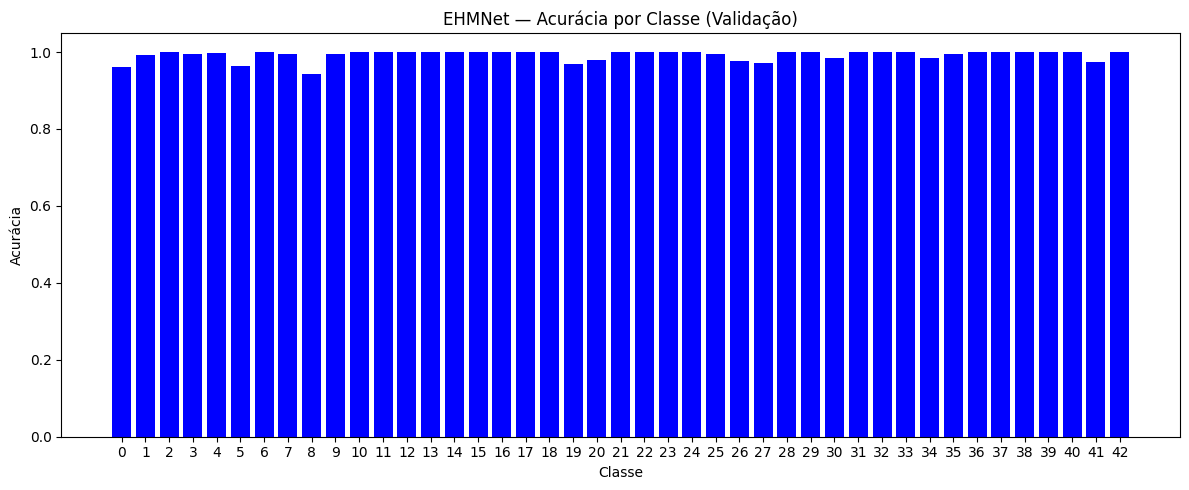

In [42]:
acc_by_class = get_acc_by_class(cm)
plot_acc_by_class(acc_by_class, title='EHMNet — Acurácia por Classe (Validação)')

In [43]:
model = load_ehmnet('best_ehmnet_resnet_exp.pth')
model.to(device)
model.eval()
_, val_acc = validate(val_loader, model, device)
print(f'Val Acc (EHMNet): {val_acc:.4f}')

Val Acc (EHMNet): 0.9932


### Executando testes com ResNet-18 (do zero)

In [44]:
model = ResNet18(num_classes=NUM_CLASSES).to(device)
print('Using GPU' if torch.cuda.is_available() else 'Using CPU')

Using GPU


In [45]:
flag_model = 'resnet18'
file_name  = 'best_resnet18_gtsrb_model.pth'

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)

for e in range(NUM_EPOCHS):
    train_loss, train_acc = train(train_loader, model, criterion, optimizer, device)
    val_loss, val_acc     = validate(val_loader, model, device)

    if val_acc > best_models[flag_model]['acc']:
        best_models[flag_model]['acc']   = val_acc
        best_models[flag_model]['model'] = model

    best_models[flag_model]['history_loss_train'].append(train_loss)
    best_models[flag_model]['history_loss_val'].append(val_loss)
    best_models[flag_model]['history_acc_train'].append(train_acc)
    best_models[flag_model]['history_acc_val'].append(val_acc)

    if (e + 1) % (NUM_EPOCHS // 10) == 0:
        print(f'Epoch {(e+1):02d}/{NUM_EPOCHS} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}')

save_model(best_models[flag_model]['model'], file_name)

Epoch 02/25 | Train Loss: 0.0660 | Train Acc: 0.9825 | Val Loss: 0.1702 | Val Acc: 0.9469
Epoch 04/25 | Train Loss: 0.0339 | Train Acc: 0.9916 | Val Loss: 0.0420 | Val Acc: 0.9895
Epoch 06/25 | Train Loss: 0.0112 | Train Acc: 0.9972 | Val Loss: 0.0634 | Val Acc: 0.9831
Epoch 08/25 | Train Loss: 0.0279 | Train Acc: 0.9927 | Val Loss: 0.1994 | Val Acc: 0.9428
Epoch 10/25 | Train Loss: 0.0062 | Train Acc: 0.9988 | Val Loss: 0.0158 | Val Acc: 0.9959
Epoch 12/25 | Train Loss: 0.0147 | Train Acc: 0.9963 | Val Loss: 0.0487 | Val Acc: 0.9863
Epoch 14/25 | Train Loss: 0.0089 | Train Acc: 0.9978 | Val Loss: 0.0205 | Val Acc: 0.9951
Epoch 16/25 | Train Loss: 0.0183 | Train Acc: 0.9956 | Val Loss: 0.0560 | Val Acc: 0.9844
Epoch 18/25 | Train Loss: 0.0185 | Train Acc: 0.9959 | Val Loss: 0.0852 | Val Acc: 0.9756
Epoch 20/25 | Train Loss: 0.0080 | Train Acc: 0.9982 | Val Loss: 0.0125 | Val Acc: 0.9972
Epoch 22/25 | Train Loss: 0.0221 | Train Acc: 0.9952 | Val Loss: 0.0621 | Val Acc: 0.9840
Epoch 24/2

'/content/models_pth/best_resnet18_gtsrb_model.pth'

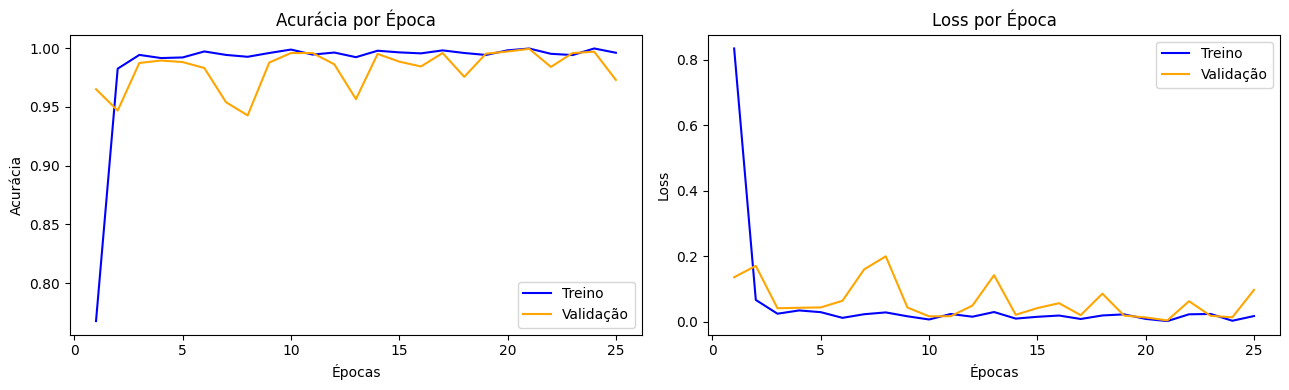

In [46]:
plot_history_metrics(
    {'train': best_models['resnet18']['history_acc_train'],
     'val':   best_models['resnet18']['history_acc_val']},
    {'train': best_models['resnet18']['history_loss_train'],
     'val':   best_models['resnet18']['history_loss_val']}
)

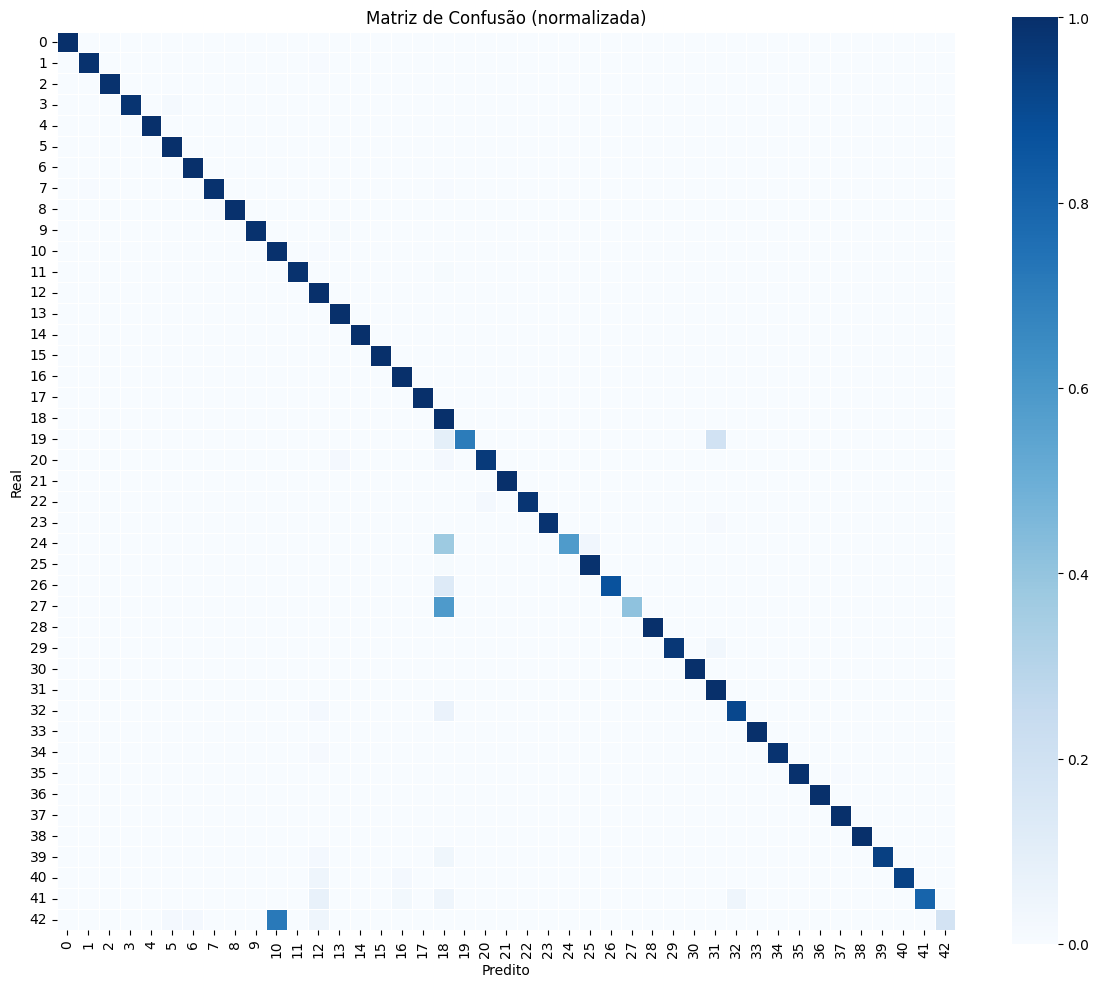

In [47]:
cm = get_confusion_matrix(val_loader, NUM_CLASSES, model)
plot_confusion_matrix(cm)

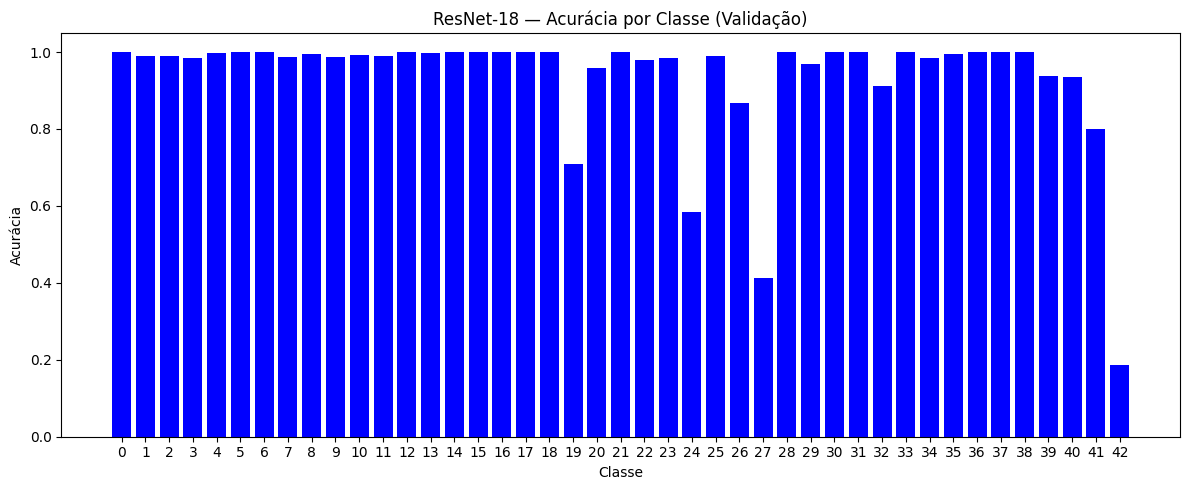

In [49]:
acc_by_class = get_acc_by_class(cm)
plot_acc_by_class(acc_by_class, title='ResNet-18 — Acurácia por Classe (Validação)')

In [50]:
model = load_resnet('best_resnet18_gtsrb_model.pth')
model.to(device)
model.eval()
_, val_acc = validate(val_loader, model, device)
print(f'Val Acc (ResNet-18): {val_acc:.4f}')

Val Acc (ResNet-18): 0.9730


### 6. Comparação Final entre Modelos

In [51]:
# Consolida resultados e salva resumo em checkpoints/ (padrão exp1)
all_results = {'ehmnet': best_models['ehmnet'], 'resnet18': best_models['resnet18']}

metrics_results = {}
for name, r in all_results.items():
    model_eval = load_ehmnet(f'best_ehmnet_resnet_exp.pth') if name == 'ehmnet' else load_resnet(f'best_resnet18_gtsrb_model.pth')
    model_eval.to(device)
    ytrue, ypred = predict(val_loader, model_eval, device)
    pca        = per_class_accuracy(ytrue, ypred)
    global_acc = float((ypred == ytrue).mean())
    macro_acc  = float(pca.mean())
    metrics_results[name] = {
        'ytrue': ytrue, 'ypred': ypred,
        'per_class_acc': pca,
        'global_acc': global_acc,
        'macro_acc': macro_acc
    }
    print(f'{name}: Global Acc: {global_acc:.4f} | Macro Acc: {macro_acc:.4f}')

to_save = {
    name: {
        'best_val_acc': r['acc'],
        'global_acc': metrics_results[name]['global_acc'],
        'macro_acc':  metrics_results[name]['macro_acc'],
        'history': {
            k: [float(x) for x in v]
            for k, v in [
                ('train_loss', r['history_loss_train']),
                ('val_loss',   r['history_loss_val']),
                ('train_acc',  r['history_acc_train']),
                ('val_acc',    r['history_acc_val']),
            ]
        }
    }
    for name, r in all_results.items()
}

with open('checkpoints/exp_resnet_summary.json', 'w') as f:
    json.dump(to_save, f, indent=2)
print('Resumo salvo em checkpoints/exp_resnet_summary.json')


ehmnet: Global Acc: 0.9932 | Macro Acc: 0.9924
resnet18: Global Acc: 0.9730 | Macro Acc: 0.9329
Resumo salvo em checkpoints/exp_resnet_summary.json


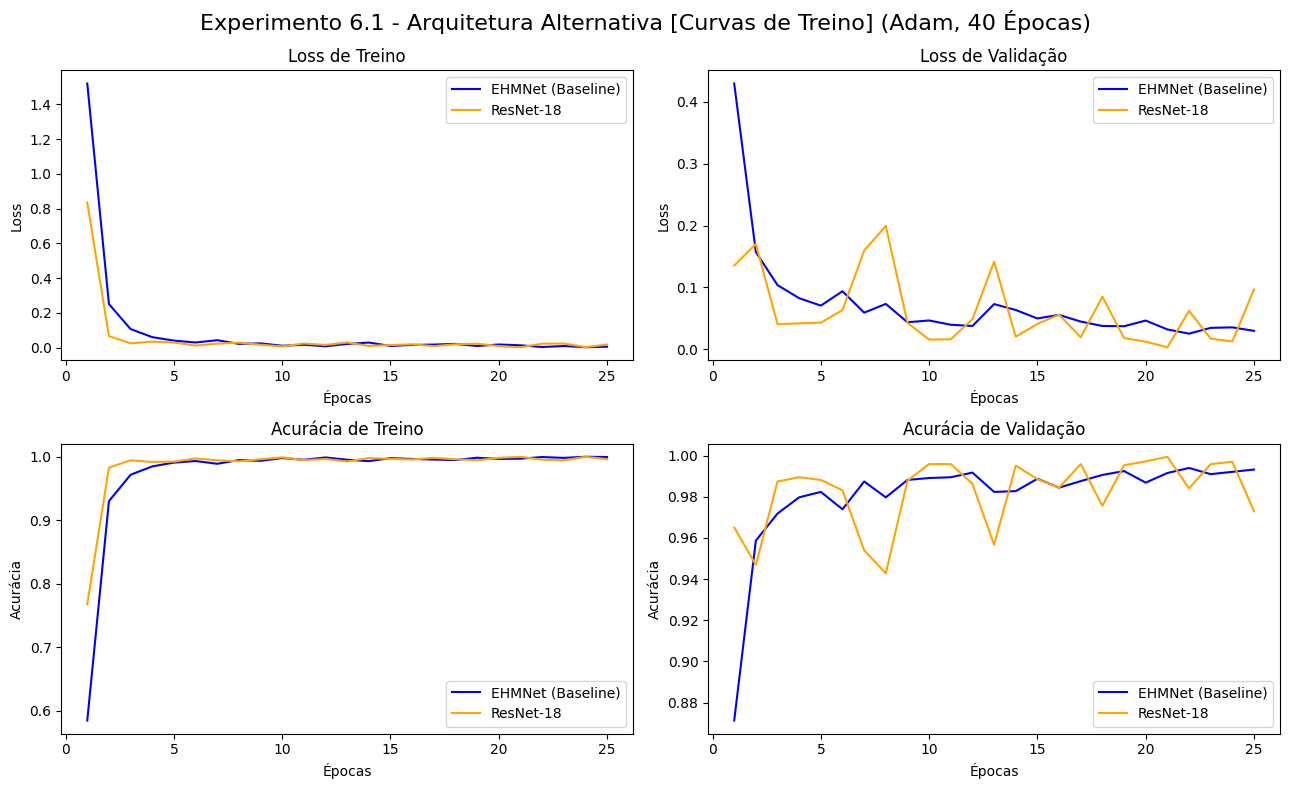

In [52]:
# Curvas lado a lado
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
epochs = range(1, NUM_EPOCHS + 1)
colors = {'ehmnet': 'blue', 'resnet18': 'orange'}
labels = {'ehmnet': 'EHMNet (Baseline)', 'resnet18': 'ResNet-18'}

for name in best_models:
    axes[0, 0].plot(epochs, best_models[name]['history_loss_train'], label=labels[name], color=colors[name])
axes[0, 0].set_title('Loss de Treino')
axes[0, 0].set_xlabel('Épocas')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()

for name in best_models:
    axes[0, 1].plot(epochs, best_models[name]['history_loss_val'], label=labels[name], color=colors[name])
axes[0, 1].set_title('Loss de Validação')
axes[0, 1].set_xlabel('Épocas')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()

for name in best_models:
    axes[1, 0].plot(epochs, best_models[name]['history_acc_train'], label=labels[name], color=colors[name])
axes[1, 0].set_title('Acurácia de Treino')
axes[1, 0].set_xlabel('Épocas')
axes[1, 0].set_ylabel('Acurácia')
axes[1, 0].legend()

for name in best_models:
    axes[1, 1].plot(epochs, best_models[name]['history_acc_val'], label=labels[name], color=colors[name])
axes[1, 1].set_title('Acurácia de Validação')
axes[1, 1].set_xlabel('Épocas')
axes[1, 1].set_ylabel('Acurácia')
axes[1, 1].legend()

plt.suptitle('Experimento 6.1 - Arquitetura Alternativa [Curvas de Treino] (Adam, 40 Épocas)', fontsize=16)
plt.tight_layout()
plt.savefig('figs/exp_resnet_curves.png', dpi=150, bbox_inches='tight')
plt.show()

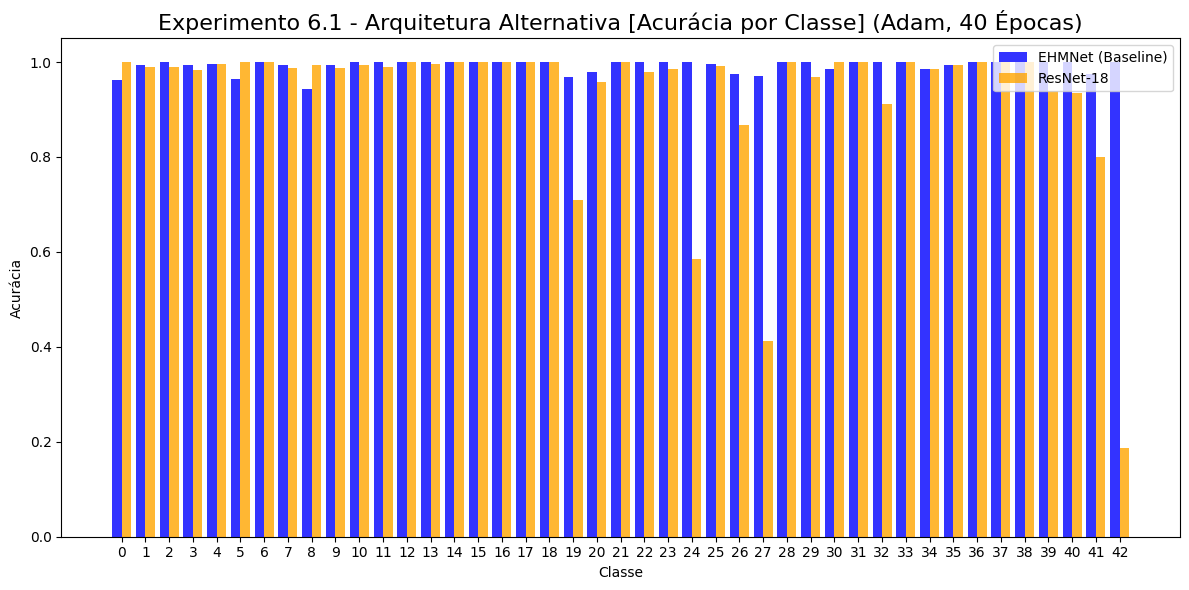

Macro Accuracy — EHMNet   : 0.9924
Macro Accuracy — ResNet-18: 0.9329


In [53]:
# Acurácia por classe lado a lado
ehmnet_cm    = get_confusion_matrix(val_loader, NUM_CLASSES, best_models['ehmnet']['model'])
resnet_cm    = get_confusion_matrix(val_loader, NUM_CLASSES, best_models['resnet18']['model'])
ehmnet_acc   = get_acc_by_class(ehmnet_cm)
resnet_acc   = get_acc_by_class(resnet_cm)

x      = np.arange(NUM_CLASSES)
width  = 0.4
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width/2, ehmnet_acc,  width, label='EHMNet (Baseline)', color='blue',   alpha=0.8)
ax.bar(x + width/2, resnet_acc,  width, label='ResNet-18',          color='orange', alpha=0.8)
ax.set_xlabel('Classe')
ax.set_ylabel('Acurácia')
ax.set_title('Experimento 6.1 - Arquitetura Alternativa [Acurácia por Classe] (Adam, 40 Épocas)', fontsize=16)
ax.set_xticks(x)
ax.legend()
plt.tight_layout()
plt.savefig('figs/exp_resnet_acc_by_class.png', dpi=150, bbox_inches='tight')
plt.show()

# Macro accuracy
print(f'Macro Accuracy — EHMNet   : {ehmnet_acc.mean():.4f}')
print(f'Macro Accuracy — ResNet-18: {resnet_acc.mean():.4f}')

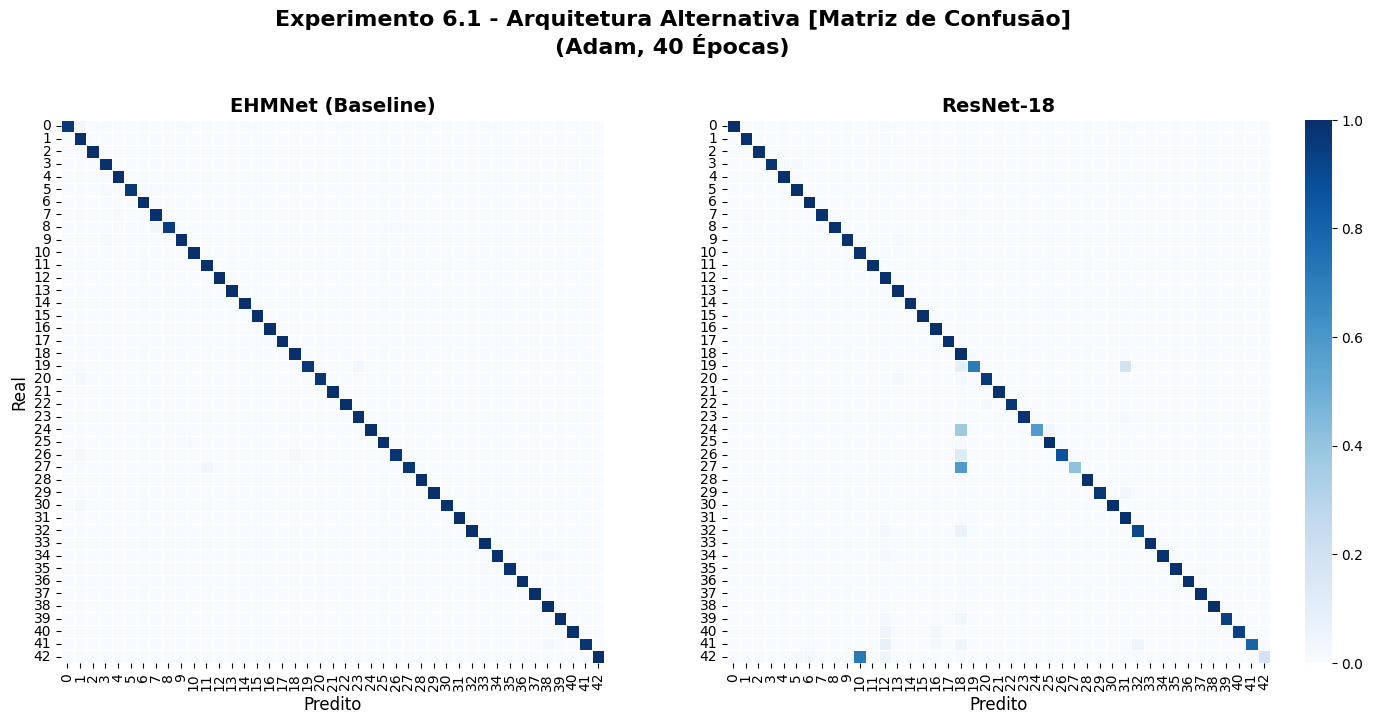

In [54]:
# Matrizes de confusão lado a lado
fig, axes = plt.subplots(1, 2, figsize=(15, 7))
cms   = {'ehmnet': ehmnet_cm, 'resnet18': resnet_cm}
names = {'ehmnet': 'EHMNet (Baseline)', 'resnet18': 'ResNet-18'}

for i, (key, cm) in enumerate(cms.items()):
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(
        cm_norm, annot=False,
        xticklabels=np.arange(NUM_CLASSES),
        yticklabels=np.arange(NUM_CLASSES),
        ax=axes[i], cmap='Blues',
        cbar=i == 1, vmin=0, vmax=1,
        linewidths=0.5, linecolor='white', square=True
    )
    axes[i].set_title(names[key], fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Predito', fontsize=12)
    axes[i].set_ylabel('Real' if i == 0 else '', fontsize=12)
    axes[i].tick_params(labelsize=10)

plt.suptitle(
    'Experimento 6.1 - Arquitetura Alternativa [Matriz de Confusão]\n(Adam, 40 Épocas)',
    fontsize=16, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('figs/exp_resnet_cm.png', dpi=150, bbox_inches='tight')
plt.show()

In [55]:
# Tabela resumo
print('=' * 55)
print('RESUMO — EXPERIMENTO 6.1: ARQUITETURA ALTERNATIVA')
print('=' * 55)
print(f'{"Modelo":<22} {"Val Acc":>10} {"Macro Acc":>12} {"Parâmetros":>13}')
print('-' * 55)
print(f'{"EHMNet (Baseline)":<22} {best_models["ehmnet"]["acc"]:>10.4f} {ehmnet_acc.mean():>12.4f} {count_params(EHMNet()):>13,}')
print(f'{"ResNet-18":<22} {best_models["resnet18"]["acc"]:>10.4f} {resnet_acc.mean():>12.4f} {count_params(ResNet18()):>13,}')
print('=' * 55)

RESUMO — EXPERIMENTO 6.1: ARQUITETURA ALTERNATIVA
Modelo                    Val Acc    Macro Acc    Parâmetros
-------------------------------------------------------
EHMNet (Baseline)          0.9940       0.9924     1,079,275
ResNet-18                  0.9994       0.9329    11,190,891


### 7. Avaliação final e geração dos arquivos

In [56]:
best_model_key = max(best_models, key=lambda x: best_models[x]['acc'])
model          = best_models[best_model_key]['model']
acc            = best_models[best_model_key]['acc']
print(f'Melhor modelo: {best_model_key}')
print(f'Acurácia     : {acc:.4f}')

Melhor modelo: resnet18
Acurácia     : 0.9994


In [57]:
model.eval()
all_preds = []
with torch.no_grad():
    for images, _ in test_loader:
        outputs = model(images.to(device))
        all_preds.append(outputs.argmax(dim=1).cpu())
y_pred = torch.cat(all_preds)

In [58]:
save_predictions(y_pred, '/content/results/predicoes_resnet18.csv', experiment_name='ResNet18 Adam Exp6')
print(f'Predicoes salvas ({len(y_pred)} imagens)')

Predicoes salvas (12630 imagens)
